# Prepare an HDF5 embeddings store from raw CT volumes

This notebook demonstrates how to go from raw `.nii`/`.nii.gz` CT volumes to the
embeddings HDF5 store that the rest of `sliceheads` (training, HPO, explainability)
expects.

**You will:** load raw NIfTI CT volumes from the MosMedData-derived demo dataset,
apply HU windowing to turn each axial slice into an 8-bit image, run a frozen
DINOv3 vision transformer over the slices to get per-slice embeddings, and write
everything into an HDF5 file using `sliceheads.store.EmbedStore` — the same
reader/writer the other notebooks (`01_full_pipeline.ipynb`, `02_add_a_head.ipynb`)
consume.


## Installation

Install the released package, or the local checkout for development. This
notebook additionally needs `nibabel` (NIfTI I/O) and `transformers` (to load
the frozen DINOv3 encoder) — both are already `sliceheads` dependencies.


In [1]:
# Released version:
# %pip install sliceheads
# For local development instead, from the repo root:
# %pip install -e .


In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import torch

from sliceheads.store import EmbedStore, validate_h5
from sliceheads.extract import extract_volume_embeddings

print('sliceheads: HDF5 preparation pipeline — ready')


sliceheads: HDF5 preparation pipeline — ready


In [ ]:
# ---- Everything the notebook depends on is set here ----

DATA_DIR = '../mosmedata/orgenized_data_with_txt_bin'   # train/val/test -> CT0/CT12
ENCODER_PATH = '../dino_model/dinov3_b16_weights'        # frozen DINOv3 encoder (local weights)

OUTPUT_DIR = 'demo_output'                                # notebook-local scratch outputs
OUTPUT_H5 = f'{OUTPUT_DIR}/prepared_embeddings.h5'

SPLITS = ['train', 'val', 'test']
LABEL_MAP = {'CT0': 0, 'CT12': 1}   # CT0 = no CT signs of pneumonia, CT12 = any involvement (CT-1/CT-2 combined)

HU_WINDOW_MIN = -1000.0   # air
HU_WINDOW_MAX = 400.0     # dense bone/contrast
SLICE_AXIS = 2            # axial slices live on the 3rd array axis: volume[:, :, z]

BATCH_SIZE = 16
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RANDOM_SEED = 42   # <- change this to pick a different demo subsample (Step 2)

# Demo dataset has 1000+ volumes; keep the notebook fast by processing a small,
# class-balanced subsample. Set to None to process every volume in DATA_DIR.
SAMPLES_PER_CLASS_PER_SPLIT = None

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(RANDOM_SEED)

print(f'device: {DEVICE}')


## Input and output format

**Raw input** (`DATA_DIR`): one folder per split, each with a `CT0` and `CT12`
subfolder of `.nii`/`.nii.gz` volumes:

```
orgenized_data_with_txt_bin/
 ├── train/
 │    ├── CT0/   study_0001.nii  ...   (label 0 — no CT signs of pneumonia)
 │    └── CT12/  study_0002.nii  ...   (label 1 — CT-1/CT-2 combined, any involvement)
 ├── val/    (same layout)
 └── test/   (same layout)
```

Each volume is a raw Hounsfield-Unit (HU) CT scan, axial slices along axis 2
(`volume[:, :, z]`). Labels come from the folder name, splits from the parent
folder — there is no separate label CSV for this dataset.

**Output** (`OUTPUT_H5`) — the HDF5 schema every other `sliceheads` notebook reads,
written by `sliceheads.store.EmbedStore`:

```
prepared_embeddings.h5
 ├── study_0001
 │    ├── embeddings: [num_slices, embedding_dim]   float32   e.g. [43, 768]
 │    └── attrs: label (0/1), split (train/val/test), patient_id
 ├── study_0002
 │    └── ...
 └── attrs (file-level): backbone_name, embedding_dim, hu_window_min/max, mean_embedding, ...
```

- **Labels:** binary — 0 = CT0 (no CT signs of pneumonia), 1 = CT12 (CT-1/CT-2 combined).
- **Split:** train / val / test, stored per sample as an attribute, taken from the folder the volume was found in.


## Step 1 — Discover volumes

Walk `DATA_DIR` and list every `.nii`/`.nii.gz` file per split and class,
without loading any of them yet.


In [4]:
def sample_id_from_path(path: Path) -> str:
    # sample_id is used as the HDF5 group name; .stem alone would leave ".nii" on .nii.gz files
    return path.name[:-7] if path.name.endswith('.nii.gz') else path.stem


all_volumes = []  # list of dicts: path, sample_id, split, class_name, label
for split in SPLITS:
    for class_name, label in LABEL_MAP.items():
        class_dir = Path(DATA_DIR) / split / class_name
        for path in sorted(class_dir.glob('*.nii*')):
            all_volumes.append({
                'path': path,
                'sample_id': sample_id_from_path(path),
                'split': split,
                'class_name': class_name,
                'label': label,
            })

print(f'Total volumes found: {len(all_volumes)}\n')
print(f'{"split":<6} {"CT0":>6} {"CT12":>6}')
for split in SPLITS:
    n0 = sum(1 for v in all_volumes if v['split'] == split and v['class_name'] == 'CT0')
    n1 = sum(1 for v in all_volumes if v['split'] == split and v['class_name'] == 'CT12')
    print(f'{split:<6} {n0:>6} {n1:>6}')


Total volumes found: 1063

split     CT0   CT12
train     152    485
val        50    161
test       52    163


## Step 2 — Subsample for the demo

Processing all 1000+ volumes works the same way but takes a while. For this demo
we pick `SAMPLES_PER_CLASS_PER_SPLIT` volumes per split/class (deterministically,
via `RANDOM_SEED`) so the notebook runs in about a minute. Set
`SAMPLES_PER_CLASS_PER_SPLIT = None` in the config cell to process everything.


In [5]:
rng = np.random.default_rng(RANDOM_SEED)

if SAMPLES_PER_CLASS_PER_SPLIT is None:
    selected_volumes = all_volumes
else:
    selected_volumes = []
    for split in SPLITS:
        for class_name in LABEL_MAP:
            group = [v for v in all_volumes if v['split'] == split and v['class_name'] == class_name]
            n = min(SAMPLES_PER_CLASS_PER_SPLIT, len(group))
            idx = rng.choice(len(group), size=n, replace=False)
            selected_volumes.extend(group[i] for i in idx)

print(f'Selected {len(selected_volumes)} / {len(all_volumes)} volumes for this demo run:')
for v in selected_volumes:
    print(f"  {v['split']:<6} {v['class_name']:<5} {v['sample_id']}")


Selected 1063 / 1063 volumes for this demo run:
  train  CT0   study_0001
  train  CT0   study_0003
  train  CT0   study_0004
  train  CT0   study_0005
  train  CT0   study_0006
  train  CT0   study_0010
  train  CT0   study_0011
  train  CT0   study_0013
  train  CT0   study_0014
  train  CT0   study_0015
  train  CT0   study_0016
  train  CT0   study_0017
  train  CT0   study_0020
  train  CT0   study_0022
  train  CT0   study_0028
  train  CT0   study_0030
  train  CT0   study_0031
  train  CT0   study_0033
  train  CT0   study_0034
  train  CT0   study_0035
  train  CT0   study_0037
  train  CT0   study_0038
  train  CT0   study_0039
  train  CT0   study_0043
  train  CT0   study_0045
  train  CT0   study_0046
  train  CT0   study_0047
  train  CT0   study_0048
  train  CT0   study_0049
  train  CT0   study_0052
  train  CT0   study_0053
  train  CT0   study_0055
  train  CT0   study_0061
  train  CT0   study_0062
  train  CT0   study_0064
  train  CT0   study_0065
  train  CT0   s

## Step 3 — Load one raw volume

Before processing everything, load a single volume with `nibabel` and look at
its raw properties: shape, dtype, HU range, and affine (voxel-to-world
transform). This is the format every volume in `DATA_DIR` is expected to be in.


In [6]:
example = selected_volumes[0]
example_img = nib.load(example['path'])
example_data = example_img.get_fdata(dtype=np.float32)

print(f"sample_id   : {example['sample_id']}")
print(f'shape (H,W,Z): {example_data.shape}   <- Z is the axial axis, sliced as data[:, :, z]')
print(f'dtype        : {example_data.dtype}')
print(f'HU range     : [{example_data.min():.1f}, {example_data.max():.1f}]')
print(f'voxel spacing: {example_img.header.get_zooms()}')
print(f'affine:\n{example_img.affine}')


sample_id   : study_0001
shape (H,W,Z): (512, 512, 43)   <- Z is the axial axis, sliced as data[:, :, z]
dtype        : float32
HU range     : [-2048.0, 1808.0]
voxel spacing: (np.float32(0.68), np.float32(0.68), np.float32(8.0))
affine:
[[-6.80000007e-01 -0.00000000e+00  0.00000000e+00  1.72315002e+02]
 [ 0.00000000e+00  6.80000007e-01  0.00000000e+00 -1.92351608e+02]
 [ 0.00000000e+00  0.00000000e+00  8.00000000e+00 -1.04819995e+03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


## Step 4 — HU windowing → 8-bit axial slices

Clip each slice to `[HU_WINDOW_MIN, HU_WINDOW_MAX]`, rescale to `[0, 255]`, and
cast to `uint8` — this is exactly the windowing `extract_volume_embeddings`
applies internally per slice before feeding the encoder, shown here on a single
middle slice for a sanity check.

We also save the fully-windowed volume back out as a `.nii.gz`, preserving the
original affine, purely as a visual/QA artifact — the real embedding step below
re-derives the same windowing directly from the raw HU data, it does not read
this file back in.


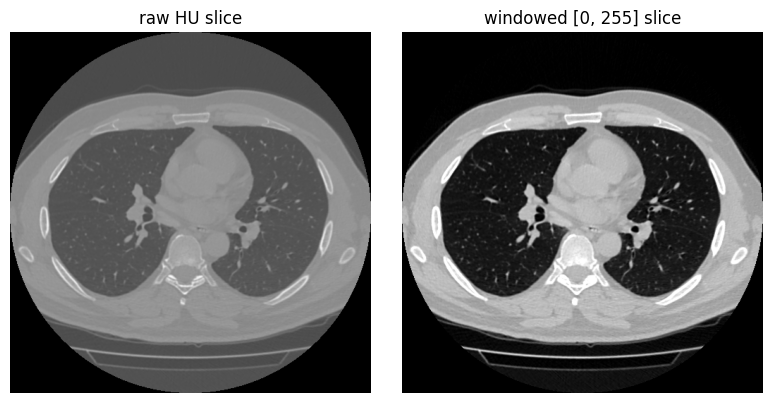

saved windowed preview: demo_output/study_0001_windowed.nii.gz
affine preserved: True


In [7]:
def window_slice(slice_2d, window_min=HU_WINDOW_MIN, window_max=HU_WINDOW_MAX):
    # clip to [window_min, window_max], rescale to [0, 255], cast to uint8
    clipped = np.clip(slice_2d, window_min, window_max)
    scaled = (clipped - window_min) / (window_max - window_min)
    return (scaled * 255.0).astype(np.uint8)


z_mid = example_data.shape[2] // 2
raw_slice = example_data[:, :, z_mid]
windowed_slice = window_slice(raw_slice)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(raw_slice.T, cmap='gray', origin='lower')
axes[0].set_title('raw HU slice')
axes[1].imshow(windowed_slice.T, cmap='gray', origin='lower')
axes[1].set_title('windowed [0, 255] slice')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

# Window every slice and save the volume back out, preserving the affine.
windowed_volume = np.stack(
    [window_slice(example_data[:, :, z]) for z in range(example_data.shape[2])], axis=2
)
windowed_path = Path(OUTPUT_DIR) / f"{example['sample_id']}_windowed.nii.gz"
nib.save(nib.Nifti1Image(windowed_volume, affine=example_img.affine), windowed_path)

reloaded = nib.load(windowed_path)
print(f'saved windowed preview: {windowed_path}')
print(f'affine preserved: {np.allclose(reloaded.affine, example_img.affine)}')


## Step 5 — Run the frozen DINOv3 encoder on one volume

`extract_volume_embeddings` loads the frozen encoder from `ENCODER_PATH`, applies
the HU windowing above to every axial slice, and returns one embedding per slice.


In [8]:
example_embeddings = extract_volume_embeddings(
    example['path'],
    ENCODER_PATH,
    window_min=HU_WINDOW_MIN,
    window_max=HU_WINDOW_MAX,
    slice_axis=SLICE_AXIS,
    batch_size=BATCH_SIZE,
    device=DEVICE,
)

embedding_dim = example_embeddings.shape[1]
print(f'embeddings shape: {example_embeddings.shape}   (num_slices, embedding_dim)')
print(f'matches volume Z : {example_embeddings.shape[0] == example_data.shape[2]}')


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 9277.88it/s]

embeddings shape: (43, 768)   (num_slices, embedding_dim)
matches volume Z : True


## Step 6 — Build the HDF5 store

Create the store with `EmbedStore.create` (writes file-level metadata), then
loop over every selected volume: extract its embeddings and `write_sample` it
into the file. This is the same `EmbedStore` API `01_full_pipeline.ipynb` and
`02_add_a_head.ipynb` read from.


In [9]:
store = EmbedStore.create(
    OUTPUT_H5,
    backbone_name='dinov3-vit-b16',
    backbone_source=ENCODER_PATH,
    embedding_dim=embedding_dim,
    dataset_name='MosMedData (CT0 vs CT1+CT2, binarized)',
    hu_window_min=HU_WINDOW_MIN,
    hu_window_max=HU_WINDOW_MAX,
    slice_axis='z',
    feature_type='cls_token',
)

slice_counts = {}
for v in selected_volumes:
    embeddings = extract_volume_embeddings(
        v['path'],
        ENCODER_PATH,
        window_min=HU_WINDOW_MIN,
        window_max=HU_WINDOW_MAX,
        slice_axis=SLICE_AXIS,
        batch_size=BATCH_SIZE,
        device=DEVICE,
    )
    store.write_sample(
        v['sample_id'],
        embeddings=embeddings,
        label=v['label'],
        split=v['split'],
        patient_id=v['sample_id'],
    )
    slice_counts[v['sample_id']] = embeddings.shape[0]
    print(f"  wrote {v['sample_id']:<14} split={v['split']:<5} label={v['label']}  n_slices={embeddings.shape[0]}")

mean_embedding = store.compute_and_write_mean_embedding()
print(f'\nmean_embedding shape: {mean_embedding.shape}')


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 8832.93it/s]

  wrote study_0001     split=train label=0  n_slices=43


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 9391.30it/s]

...

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 9693.30it/s]

  wrote study_1058     split=test  label=1  n_slices=36


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 8941.63it/s]

  wrote study_1062     split=test  label=1  n_slices=46

mean_embedding shape: (768,)


## Step 7 — Validate the file

`validate_h5` checks every sample has `embeddings`/`label`/`split`, labels are
binary, embedding dimensions are consistent, and (where `patient_id` is set)
there's no patient overlap across splits.


In [10]:
validate_h5(OUTPUT_H5)
print('Validation passed ✓')


Validation passed ✓


## Step 8 — Sanity checks

Reload the file through `EmbedStore` and print the checks a new user should run
after building any embedding store: sample counts, slice counts, embedding
shape, and class balance per split.


In [11]:
store = EmbedStore(OUTPUT_H5)

print(f'Volumes found in DATA_DIR : {len(all_volumes)}')
print(f'Volumes written to HDF5   : {len(selected_volumes)}\n')

counts = np.array(list(slice_counts.values()))
print(f'Slice counts per volume   : min={counts.min()}  mean={counts.mean():.1f}  max={counts.max()}\n')

print(f'{"split":<6} {"n":>4} {"label 0":>8} {"label 1":>8} {"embedding_dim":>14}')
for split in SPLITS:
    embeddings_list, labels, ids = store.load_split(split)
    dims = {e.shape[1] for e in embeddings_list}
    print(f'{split:<6} {len(ids):>4} {int((labels == 0).sum()):>8} {int((labels == 1).sum()):>8} {str(dims):>14}')


Volumes found in DATA_DIR : 1063
Volumes written to HDF5   : 1063

Slice counts per volume   : min=31  mean=41.9  max=67

split     n  label 0  label 1  embedding_dim
train   637      152      485          {768}
val     211       50      161          {768}


test    215       52      163          {768}


## Results

| Split | Volumes found | Volumes in demo store | Embedding dim |
|-------|--------------:|-----------------------:|--------------:|
| train | see Step 1    | see Step 8              | 768 |
| val   | see Step 1    | see Step 8              | 768 |
| test  | see Step 1    | see Step 8              | 768 |

`prepared_embeddings.h5` now has the exact schema `01_full_pipeline.ipynb` and
`02_add_a_head.ipynb` expect — swap `dataset_normal.h5` for
`notebooks/demo_output/prepared_embeddings.h5` (or point `SAMPLES_PER_CLASS_PER_SPLIT`
at `None` and rerun to build the full dataset) to train heads on it directly.


## Troubleshooting

- **FileNotFoundError on `DATA_DIR`/`ENCODER_PATH`:** check the relative paths in
  the config cell — they assume the notebook runs from `notebooks/`.
- **No volumes found for a split/class:** confirm the folder layout matches
  `DATA_DIR/{train,val,test}/{CT0,CT12}/*.nii*` exactly.
- **`validate_h5` raises "No samples with split='train'/'test'"**: make sure
  `SAMPLES_PER_CLASS_PER_SPLIT` (or your own subsampling) still includes at
  least one volume in both the `train` and `test` splits.
- **`validate_h5` raises "binary-only"**: the file must contain both label 0
  (CT0) and label 1 (CT12) volumes somewhere.
- **Embedding-dimension mismatch:** all volumes must go through the same
  `ENCODER_PATH`; don't mix embeddings from different encoders in one file.
- **CUDA not available:** `DEVICE` in the config cell falls back to `'cpu'`
  automatically — extraction is just slower, not broken.
- **Too few samples per class:** with the default `SAMPLES_PER_CLASS_PER_SPLIT = 2`,
  per-split metrics computed downstream will be very noisy — that's expected
  for a fast demo, increase it (or set it to `None`) for real experiments.


## Conclusion

In this notebook we discovered raw NIfTI CT volumes, applied HU windowing to
turn axial slices into 8-bit images, ran a frozen DINOv3 encoder over those
slices, and wrote the resulting per-slice embeddings into an HDF5 store with
`sliceheads.store.EmbedStore` — validated against the same schema the rest of
the package reads. The same workflow applies to any new CT dataset: point
`DATA_DIR` at your own `{split}/{class}/*.nii*` layout, update `LABEL_MAP`, and
rerun.
